In [1]:
import os

os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import cv2, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy("mixed_float16")

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass



2026-05-19 15:38:43.177652: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779205123.191238      56 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779205123.195330      56 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-19 15:38:43.211727: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
base_dir = "../input/cassava-leaf-disease-classification"
print("Files in base_dir:", os.listdir(base_dir))



Files in base_dir: ['train.csv.zip', 'sample_submission.csv.zip', 'test.zip', 'test_tfrecords.zip', 'train_tfrecords.zip', 'test_images.zip', 'train.csv', 'test_images', 'test_tfrecords', 'cassava-leaf-disease-classification', 'train_tfrecords', 'train_images', 'train.zip', 'description.md', 'train_images.zip', 'sample_submission.csv', 'label_num_to_disease_map.json']


In [3]:
train_labels = pd.read_csv(os.path.join(base_dir, "train.csv"))
train_labels["label"] = train_labels["label"].astype(str)
print(train_labels.head())



         image_id label
0  1000015157.jpg     0
1  1000201771.jpg     3
2   100042118.jpg     1
3  1000723321.jpg     1
4  1000812911.jpg     3


In [4]:
BATCH_SIZE = 20
EPOCHS = 20
TARGET_SIZE = 224



In [5]:
# Use tf.data instead of ImageDataGenerator for faster, cached loading
# Split paths/labels once and build efficient pipelines with caching & prefetch
train_image_paths = [
    os.path.join(base_dir, "train_images", fname) for fname in train_labels["image_id"]
]
train_label_ints = train_labels["label"].astype(int).values

# Stratified split to keep class balance
train_paths, val_paths, train_lbls, val_lbls = train_test_split(
    train_image_paths,
    train_label_ints,
    test_size=0.2,
    random_state=42,
    stratify=train_label_ints,
)


def _process_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [TARGET_SIZE, TARGET_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label


train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_lbls))
train_ds = (
    train_ds.map(_process_image, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_lbls))
val_ds = (
    val_ds.map(_process_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)



I0000 00:00:1779205129.863950      56 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:05:00.0, compute capability: 8.6


In [6]:
from tensorflow.keras.applications import EfficientNetB0

eff_base = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(TARGET_SIZE, TARGET_SIZE, 3),
)

model = models.Sequential(
    [
        eff_base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(5, activation="softmax", name="Output"),
    ]
)
model.summary()



16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 4,013,953 (15.31 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)



In [8]:
model_save = ModelCheckpoint(
    "./EffNetB0_512_8_best_weights.weights.h5",
    save_best_only=True,
    save_weights_only=True,
    monitor="val_loss",
    mode="min",
    verbose=1,
)

early_stop = EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=5,
    mode="min",
    verbose=1,
    restore_best_weights=True,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.3, patience=2, min_delta=0.001, mode="min", verbose=1
)



In [9]:
# Fit using the tf.data pipelines (no manual steps needed)
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[model_save, early_stop, reduce_lr],
)



Epoch 1/20


I0000 00:00:1779205164.602878     106 service.cc:148] XLA service 0x7f824c22ee50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779205164.602922     106 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-05-19 15:39:25.133292: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779205168.179124     106 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1779205172.272872     106 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1779205172.387698     106 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1779205172.704292     106 gpu_ti

  1/749 ━━━━━━━━━━━━━━━━━━━━ 13:38:38 66s/step - accuracy: 0.2000 - loss: 1.8204

I0000 00:00:1779205197.187221     106 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


747/749 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6717 - loss: 0.8772

E0000 00:00:1779205218.457589     109 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1779205218.572639     109 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1779205218.894162     109 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1779205219.011415     109 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1779205219.604268     109 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

749/749 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6718 - loss: 0.8769

2026-05-19 15:40:44.785040: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2298', 176 bytes spill stores, 200 bytes spill loads

2026-05-19 15:40:44.859286: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2298', 596 bytes spill stores, 528 bytes spill loads

2026-05-19 15:40:45.021704: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2298', 4 bytes spill stores, 4 bytes spill loads

2026-05-19 15:40:52.204851: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2298', 176 bytes spill stores, 200 bytes spill loads

E0000 00:00:1779205253.289751     106 gpu_timer.cc:82] D


Epoch 1: val_loss improved from inf to 1.74018, saving model to ./EffNetB0_512_8_best_weights.weights.h5
749/749 ━━━━━━━━━━━━━━━━━━━━ 125s 79ms/step - accuracy: 0.6719 - loss: 0.8767 - val_accuracy: 0.0502 - val_loss: 1.7402 - learning_rate: 0.0010
Epoch 2/20
748/749 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7804 - loss: 0.5899
Epoch 2: val_loss did not improve from 1.74018
749/749 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.7805 - loss: 0.5898 - val_accuracy: 0.1212 - val_loss: 2.1943 - learning_rate: 0.0010
Epoch 3/20
749/749 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8272 - loss: 0.4726
Epoch 3: val_loss improved from 1.74018 to 1.37727, saving model to ./EffNetB0_512_8_best_weights.weights.h5
749/749 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.8272 - loss: 0.4725 - val_accuracy: 0.5896 - val_loss: 1.3773 - learning_rate: 0.0010
Epoch 4/20
749/749 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8608 - loss: 0.3858
Epoch 4: val_loss did not improve from 1.37727


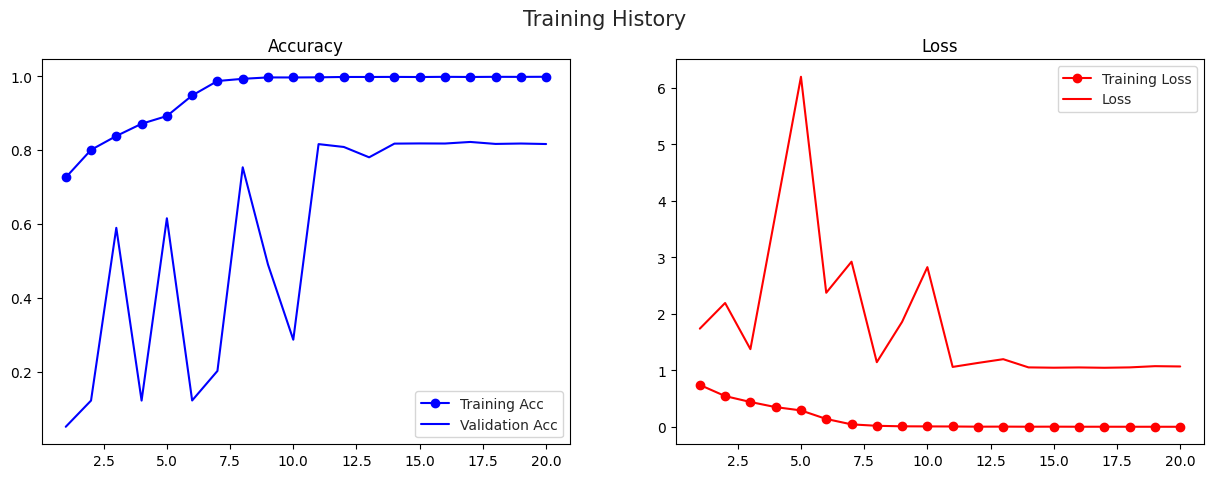

In [10]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.set_style("white")
plt.suptitle("Training History", size=15)

ax1.plot(epochs_range, acc, "bo-", label="Training Acc")
ax1.plot(epochs_range, val_acc, "b-", label="Validation Acc")
ax1.set_title("Accuracy")
ax1.legend()

ax2.plot(epochs_range, loss, "ro-", label="Training Loss")
ax2.plot(epochs_range, val_loss, "r-", label="Loss")
ax2.set_title("Loss")
ax2.legend()
plt.show()



In [11]:
sub = pd.read_csv(os.path.join(base_dir, "sample_submission.csv"))
print(sub.head())



         image_id  label
0  1234294272.jpg      4
1  1234332763.jpg      4
2  1234375577.jpg      4
3  1234555380.jpg      4
4  1234571117.jpg      4


In [12]:
# Efficient inference using tf.data (batching, caching, prefetch)
model.load_weights("./EffNetB0_512_8_best_weights.weights.h5")

test_image_paths = [
    os.path.join(base_dir, "test_images", img_id) for img_id in sub["image_id"]
]


def _load_test_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [TARGET_SIZE, TARGET_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img


test_ds = tf.data.Dataset.from_tensor_slices(test_image_paths)
test_ds = (
    test_ds.map(_load_test_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

preds = np.argmax(model.predict(test_ds, verbose=0), axis=1)
sub["label"] = preds



2026-05-19 15:47:21.448981: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2279', 452 bytes spill stores, 496 bytes spill loads

2026-05-19 15:47:21.577891: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2279', 156 bytes spill stores, 156 bytes spill loads

E0000 00:00:1779205643.510919     106 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1779205643.631102     106 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1779205643.976084     106 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may b

In [13]:
submission_path = "submission.csv"
sub.to_csv(submission_path, index=False)
print(f"Submission file written to {submission_path}")

Submission file written to submission.csv
